In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf

# Use a curated list of 50 large S&P 500 stocks
tickers = [
    'AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'META', 'TSLA', 'BRK-B', 'UNH', 'XOM',
    'JNJ', 'JPM', 'V', 'PG', 'MA', 'HD', 'CVX', 'MRK', 'ABBV', 'PEP',
    'KO', 'BAC', 'PFE', 'COST', 'TMO', 'DIS', 'CSCO', 'WMT', 'ABT', 'MCD',
    'ACN', 'LIN', 'DHR', 'VZ', 'ADBE', 'TXN', 'NEE', 'PM', 'RTX', 'ORCL',
    'WFC', 'BMY', 'QCOM', 'HON', 'UPS', 'LOW', 'INTU', 'SPGI', 'CAT', 'GS'
]

print(f"Total tickers: {len(tickers)}")
print(tickers[:10])

Total tickers: 50
['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'META', 'TSLA', 'BRK-B', 'UNH', 'XOM']


In [2]:
# Download 3 years of daily price data
raw_data = yf.download(tickers, start='2021-01-01', end='2024-01-01', auto_adjust=True)

# Keep only closing prices
prices = raw_data['Close']

# Drop any stocks with too much missing data
prices = prices.dropna(axis=1, thresh=int(0.95 * len(prices)))

print(f"Data shape: {prices.shape}")
print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
print(f"Stocks loaded: {prices.shape[1]}")
prices.head()

[*********************100%***********************]  50 of 50 completed


Data shape: (753, 50)
Date range: 2021-01-04 00:00:00 to 2023-12-29 00:00:00
Stocks loaded: 50


Ticker,AAPL,ABBV,ABT,ACN,ADBE,AMZN,BAC,BMY,BRK-B,CAT,...,TMO,TSLA,TXN,UNH,UPS,V,VZ,WFC,WMT,XOM
2021-01-04,125.740852,85.339409,98.566505,236.703064,485.339996,159.331497,26.464048,49.818535,228.449997,164.929352,...,465.204956,243.256668,139.115295,319.662170,129.238098,209.139343,42.235970,26.190462,45.454315,33.466637
2021-01-05,127.295486,86.221863,99.786072,238.050613,485.690002,160.925507,26.666735,49.956512,227.470001,166.278488,...,471.022247,245.036667,140.135803,315.363403,127.439224,206.018021,42.042202,26.922386,45.212349,35.079487
2021-01-06,123.010521,85.477028,99.578278,240.653336,466.309998,156.919006,28.332308,50.078259,230.270004,175.532288,...,478.407257,251.993332,140.830429,328.598053,127.060448,204.202881,42.551754,28.827145,45.494637,35.974613
2021-01-07,127.208046,86.391876,100.544914,242.923813,477.739990,158.108002,28.957996,50.613945,232.880005,175.867310,...,493.315216,272.013336,144.020645,333.866333,125.450890,205.345749,42.456009,29.479700,45.491531,36.256866
2021-01-08,128.306000,86.845238,100.824936,243.809937,485.100006,159.134995,28.667177,50.719452,234.029999,175.894455,...,505.117371,293.339996,146.782028,332.366364,124.969643,206.920837,41.926491,29.268063,45.485336,36.660080


In [3]:
# Resample daily prices to monthly (last trading day of each month)
monthly_prices = prices.resample('ME').last()

# Calculate monthly returns
monthly_returns = monthly_prices.pct_change()

# Drop the first row (NaN since no previous month)
monthly_returns = monthly_returns.dropna(how='all')

print(f"Monthly returns shape: {monthly_returns.shape}")
print(f"Date range: {monthly_returns.index[0]} to {monthly_returns.index[-1]}")
monthly_returns.head()

Monthly returns shape: (35, 50)
Date range: 2021-02-28 00:00:00 to 2023-12-31 00:00:00


Ticker,AAPL,ABBV,ABT,ACN,ADBE,AMZN,BAC,BMY,BRK-B,CAT,...,TMO,TSLA,TXN,UNH,UPS,V,VZ,WFC,WMT,XOM
2021-02-28,-0.079712,0.051327,-0.030828,0.037120,0.001962,-0.035328,0.170658,-0.001628,0.055470,0.180704,...,-0.116971,-0.148740,0.039713,-0.004077,0.024705,0.100749,0.010046,0.214339,-0.075237,0.233125
2021-03-31,0.007339,0.004455,0.000501,0.101036,0.034155,0.000372,0.120201,0.037378,0.062201,0.074069,...,0.014583,-0.011207,0.097057,0.123929,0.077045,-0.003107,0.051537,0.080177,0.049855,0.026853
2021-04-30,0.076218,0.042836,0.005682,0.052913,0.069357,0.120663,0.047558,-0.011247,0.076252,-0.011769,...,0.030347,0.062147,-0.039599,0.071841,0.199247,0.103103,0.004501,0.153059,0.030038,0.025255
2021-05-31,-0.050497,0.015247,-0.028564,-0.026934,-0.007397,-0.070470,0.045892,0.052868,0.052700,0.056858,...,-0.001552,-0.118713,0.051576,0.032899,0.057726,-0.025389,-0.022495,0.039332,0.019139,0.034597
2021-06-30,0.099109,-0.004947,-0.006172,0.044762,0.160649,0.067355,-0.023271,0.016737,-0.039801,-0.097271,...,0.075084,0.087137,0.013065,-0.024309,-0.030895,0.028685,-0.008143,-0.030608,-0.007111,0.080692


In [4]:
# Calculate 12-1 momentum signal
# For each month, sum returns from t-12 to t-2 (skipping most recent month)
momentum = monthly_returns.shift(1).rolling(window=11).sum()

# Drop rows with insufficient data
momentum = momentum.dropna(how='all')

print(f"Momentum signal shape: {momentum.shape}")
print(f"Date range: {momentum.index[0]} to {momentum.index[-1]}")
momentum.head()

Momentum signal shape: (24, 50)
Date range: 2022-01-31 00:00:00 to 2023-12-31 00:00:00


Ticker,AAPL,ABBV,ABT,ACN,ADBE,AMZN,BAC,BMY,BRK-B,CAT,...,TMO,TSLA,TXN,UNH,UPS,V,VZ,WFC,WMT,XOM
2022-01-31,0.329860,0.340331,0.157618,0.580437,0.261458,0.056659,0.463327,0.062544,0.286361,0.173582,...,0.292087,0.393593,0.154144,0.458729,0.393145,0.146884,-0.014762,0.529366,0.057629,0.412672
2022-02-28,0.393860,0.310500,0.097282,0.398454,0.201725,-0.010843,0.329756,0.114031,0.277780,-0.027447,...,0.280258,0.428725,0.073090,0.403918,0.311848,0.089788,0.011978,0.436327,0.099139,0.420926
2022-03-31,0.332455,0.385525,0.043117,0.191189,0.042883,0.015458,0.167509,0.134905,0.242510,-0.170875,...,0.201509,0.369163,-0.076894,0.286972,0.282966,0.050015,-0.031294,0.352612,0.016025,0.437903
2022-04-30,0.313710,0.439731,0.018699,0.205392,-0.052260,-0.043767,0.057091,0.217491,0.264127,0.028761,...,0.257524,0.545025,0.042062,0.289960,0.102918,-0.026945,-0.086661,0.107554,0.092054,0.465823
2022-05-31,0.267077,0.338237,0.010024,0.125646,-0.175828,-0.210822,-0.123202,0.195295,0.126193,-0.078678,...,0.195197,0.471793,-0.081620,0.254277,-0.115584,-0.040516,-0.144186,-0.031448,0.100245,0.463434


In [5]:
# Rank stocks each month (higher momentum = higher rank)
ranks = momentum.rank(axis=1, ascending=True)

# Define top and bottom deciles (top 10 and bottom 10 out of 50)
n_stocks = momentum.shape[1]
top_cutoff = n_stocks * 0.8   # top 20% = winners (long)
bottom_cutoff = n_stocks * 0.2  # bottom 20% = losers (short)

# Assign positions: +1 for winners, -1 for losers, 0 for middle
positions = pd.DataFrame(0, index=ranks.index, columns=ranks.columns)
positions[ranks > top_cutoff] = 1    # long winners
positions[ranks < bottom_cutoff] = -1  # short losers

print(f"Long positions per month: {(positions == 1).sum(axis=1).mean():.1f}")
print(f"Short positions per month: {(positions == -1).sum(axis=1).mean():.1f}")
positions.head()

Long positions per month: 10.0
Short positions per month: 9.0


Ticker,AAPL,ABBV,ABT,ACN,ADBE,AMZN,BAC,BMY,BRK-B,CAT,...,TMO,TSLA,TXN,UNH,UPS,V,VZ,WFC,WMT,XOM
2022-01-31,0,0,0,1,0,-1,1,-1,0,0,...,0,0,0,0,0,-1,-1,1,-1,0
2022-02-28,0,0,-1,0,0,-1,0,0,0,-1,...,0,1,-1,1,0,-1,-1,1,0,1
2022-03-31,1,1,0,0,0,-1,0,0,0,-1,...,0,1,-1,0,0,0,-1,1,-1,1
2022-04-30,1,1,0,0,-1,-1,0,0,1,0,...,0,1,0,1,0,-1,-1,0,0,1
2022-05-31,1,1,0,0,-1,-1,-1,0,0,0,...,0,1,0,1,0,0,-1,0,0,1


In [6]:
# Align returns with positions (shift positions forward 1 month)
# We decide positions based on momentum, then hold for the NEXT month
position_returns = positions.shift(1) * monthly_returns

# Average return across all long and short positions each month
portfolio_returns = position_returns.mean(axis=1)

# Drop NaN rows
portfolio_returns = portfolio_returns.dropna()

print(f"Portfolio monthly returns shape: {portfolio_returns.shape}")
print(f"\nAverage monthly return: {portfolio_returns.mean():.4f}")
print(f"Monthly return std dev: {portfolio_returns.std():.4f}")
portfolio_returns.head(10)

Portfolio monthly returns shape: (23,)

Average monthly return: -0.0003
Monthly return std dev: 0.0126


2022-02-28   -0.009615
2022-03-31    0.005819
2022-04-30   -0.003864
2022-05-31   -0.003354
2022-06-30    0.009855
2022-07-31   -0.007720
2022-08-31   -0.005006
2022-09-30    0.017080
2022-10-31    0.014429
2022-11-30   -0.006059
Freq: ME, dtype: float64

In [7]:
# Annualized return
annualized_return = portfolio_returns.mean() * 12
print(f"Annualized Return: {annualized_return:.2%}")

# Annualized volatility
annualized_vol = portfolio_returns.std() * np.sqrt(12)
print(f"Annualized Volatility: {annualized_vol:.2%}")

# Sharpe Ratio (assuming risk-free rate of 4%)
risk_free_rate = 0.04
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# Max Drawdown
cumulative = (1 + portfolio_returns).cumprod()
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()
print(f"Max Drawdown: {max_drawdown:.2%}")

# Win rate
win_rate = (portfolio_returns > 0).mean()
print(f"Win Rate: {win_rate:.2%}")

Annualized Return: -0.33%
Annualized Volatility: 4.37%
Sharpe Ratio: -0.99
Max Drawdown: -6.24%
Win Rate: 52.17%


In [8]:
# T-test: is the average monthly return significantly different from zero?
t_stat, p_value = stats.ttest_1samp(portfolio_returns, 0)

print("=== STATISTICAL VALIDATION ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print("Result: NOT statistically significant (p >= 0.05)")

print(f"\nNumber of monthly observations: {len(portfolio_returns)}")
print(f"Mean monthly return: {portfolio_returns.mean():.4f}")
print(f"Std dev of monthly returns: {portfolio_returns.std():.4f}")

=== STATISTICAL VALIDATION ===
T-statistic: -0.1051
P-value: 0.9172
Result: NOT statistically significant (p >= 0.05)

Number of monthly observations: 23
Mean monthly return: -0.0003
Std dev of monthly returns: 0.0126


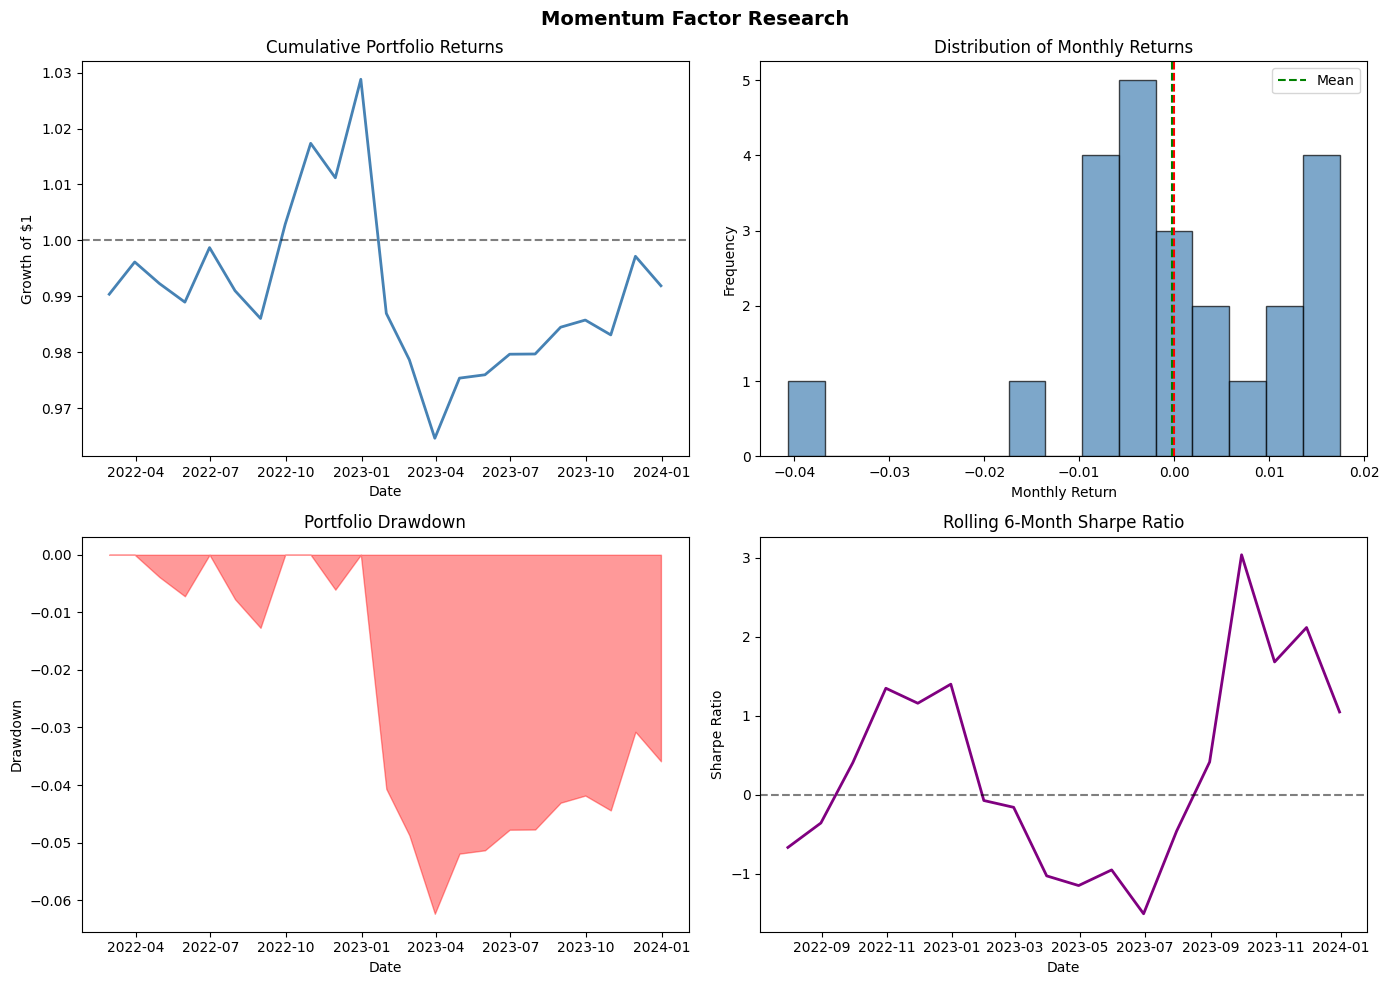

Chart saved as momentum_results.png!


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Momentum Factor Research', 
             fontsize=14, fontweight='bold')

# Chart 1 — Cumulative Portfolio Returns
cumulative = (1 + portfolio_returns).cumprod()
axes[0, 0].plot(cumulative.index, cumulative.values, color='steelblue', linewidth=2)
axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Cumulative Portfolio Returns')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Growth of $1')

# Chart 2 — Monthly Returns Distribution
axes[0, 1].hist(portfolio_returns, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].axvline(x=portfolio_returns.mean(), color='green', linestyle='--', linewidth=1.5, label='Mean')
axes[0, 1].set_title('Distribution of Monthly Returns')
axes[0, 1].set_xlabel('Monthly Return')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Chart 3 — Drawdown
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
axes[1, 0].fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.4)
axes[1, 0].set_title('Portfolio Drawdown')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Drawdown')

# Chart 4 — Rolling Sharpe Ratio (6 month window)
rolling_sharpe = portfolio_returns.rolling(6).mean() / portfolio_returns.rolling(6).std() * np.sqrt(12)
axes[1, 1].plot(rolling_sharpe.index, rolling_sharpe.values, color='purple', linewidth=2)
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Rolling 6-Month Sharpe Ratio')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Sharpe Ratio')

plt.tight_layout()
plt.savefig('momentum_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as momentum_results.png!")

In [10]:
# Split into in-sample and out-of-sample
split_date = '2023-01-01'

in_sample = portfolio_returns[portfolio_returns.index < split_date]
out_of_sample = portfolio_returns[portfolio_returns.index >= split_date]

# In-sample stats
in_ann_return = in_sample.mean() * 12
in_sharpe = (in_ann_return - 0.04) / (in_sample.std() * np.sqrt(12))
t_in, p_in = stats.ttest_1samp(in_sample, 0)

# Out-of-sample stats
out_ann_return = out_of_sample.mean() * 12
out_sharpe = (out_ann_return - 0.04) / (out_of_sample.std() * np.sqrt(12))
t_out, p_out = stats.ttest_1samp(out_of_sample, 0)

print("=== IN-SAMPLE (2022 - 2022) ===")
print(f"Annualized Return: {in_ann_return:.2%}")
print(f"Sharpe Ratio: {in_sharpe:.2f}")
print(f"T-stat: {t_in:.4f} | P-value: {p_in:.4f}")

print("\n=== OUT-OF-SAMPLE (2023 - 2024) ===")
print(f"Annualized Return: {out_ann_return:.2%}")
print(f"Sharpe Ratio: {out_sharpe:.2f}")
print(f"T-stat: {t_out:.4f} | P-value: {p_out:.4f}")

=== IN-SAMPLE (2022 - 2022) ===
Annualized Return: 3.16%
Sharpe Ratio: -0.23
T-stat: 0.8339 | P-value: 0.4238

=== OUT-OF-SAMPLE (2023 - 2024) ===
Annualized Return: -3.53%
Sharpe Ratio: -1.53
T-stat: -0.7166 | P-value: 0.4886
